In [4]:
from dotenv import load_dotenv

load_dotenv()

True

## Creating subagents

Creating subagents to be specialized in different tasks and work together helps to better manage the context window for each agent.
In a way, this is similar to assigning subagents as tools for the main agent to call.

In [5]:
from langchain.tools import tool

@tool
def square_root(x: float) -> float:
    """Calculate the square root of a number"""
    return x ** 0.5

@tool
def square(x: float) -> float:
    """Calculate the square of a number"""
    return x ** 2

In [6]:
from langchain.agents import create_agent

# create subagents

subagent_1 = create_agent(
    model='google_genai:gemini-3.1-flash-lite',
    tools=[square_root]
)

subagent_2 = create_agent(
    model='google_genai:gemini-3.1-flash-lite',
    tools=[square]
)

## Calling subagents

In [8]:
from langchain.messages import HumanMessage

@tool
def call_subagent_1(x: float) -> float:
    """Call subagent 1 in order to calculate the square root of a number"""
    response = subagent_1.invoke({"messages": [HumanMessage(content=f"Calculate the square root of {x}")]})
    return response["messages"][-1].content

@tool
def call_subagent_2(x: float) -> float:
    """Call subagent 2 in order to calculate the square of a number"""
    response = subagent_2.invoke({"messages": [HumanMessage(content=f"Calculate the square of {x}")]})
    return response["messages"][-1].content

## Creating the main agent

main_agent = create_agent(
    model='google_genai:gemini-3.1-flash-lite',
    tools=[call_subagent_1, call_subagent_2],
    system_prompt="You are a helpful assistant who can call subagents to calculate the square root or square of a number.")

## Test

In [9]:
question = "What is the square root of 456?"

response = main_agent.invoke({"messages": [HumanMessage(content=question)]})

In [10]:
from pprint import pprint

pprint(response)

{'messages': [HumanMessage(content='What is the square root of 456?', additional_kwargs={}, response_metadata={}, id='4e6526cf-929a-4faa-9588-3978ee56526c'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'call_subagent_1', 'arguments': '{"x": 456}'}, '__gemini_function_call_thought_signatures__': {'call_780841': 'EnMKcQFpFH0T1Y3545ga/90DIUTsFQ0rjlJcvgWvmWTd5FD/v/da+EwUGNcQWgUBeFIih9Yf69ie5LslKD31953hhnwhkjQk58PX8YwG0AA1mmNyn4gTjqpWHreFKCcZ3/CKlKEYlBjPpSG0mXFShZSGWpGk'}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0f672-0e24-7ec0-90a5-7bf03a9a27e1-0', tool_calls=[{'name': 'call_subagent_1', 'args': {'x': 456}, 'id': 'call_780841', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 142, 'output_tokens': 19, 'total_tokens': 161, 'input_token_details': {'cache_read': 0}}),
              ToolMessage(content=[{'type': 't

This is an instance where tracing would be better to visualize what is going on within the individual subagent.
The messages here are only from the perspective of the main agent, displaying the final output from the tool call.
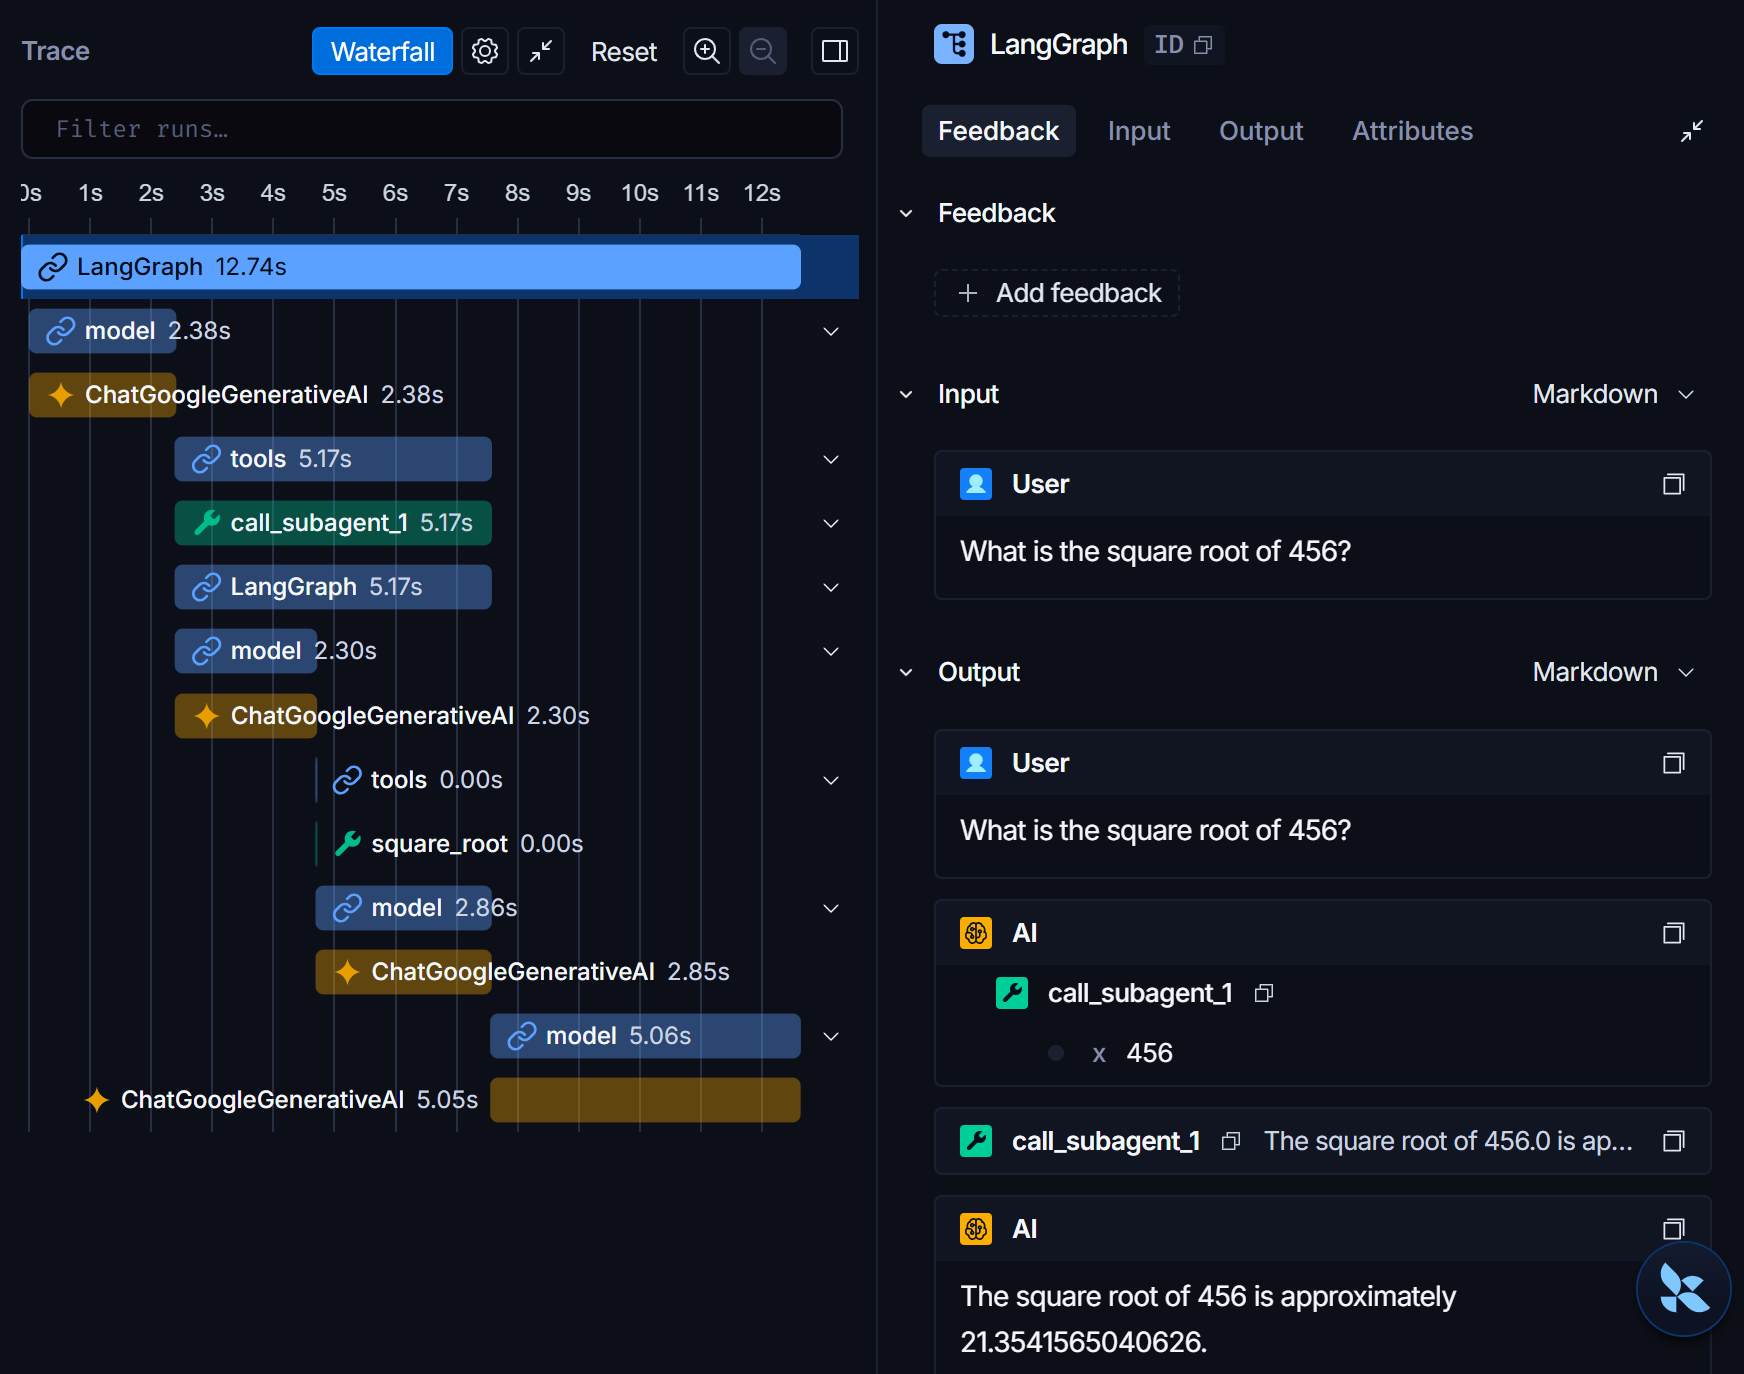